Logistic Regression Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



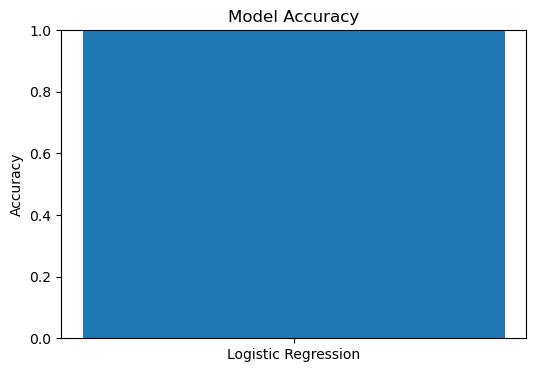

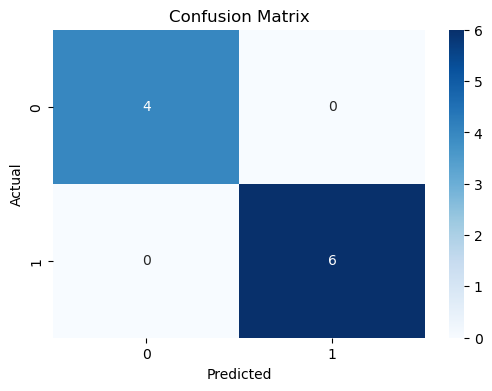

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load CSV
file_path = r"C:\Users\USER\Documents\GitHub\ml-class\input.csv"
data = pd.read_csv(file_path)

# Create Target Column (1 = High Salary)
data["target"] = (data["Salary"] > 76000).astype(int)

# Encode City (One Hot Encoding)
data = pd.get_dummies(data, columns=["City"], drop_first=True)

# Drop Name (non-numeric)
data = data.drop("Name", axis=1)

# Split into X and y
X = data.drop("target", axis=1)
y = data["target"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, pred)
print("Logistic Regression Accuracy:", acc)
print(classification_report(y_test, pred))

# -------------------------
# 📊 1. Accuracy Bar Graph
# -------------------------
plt.figure(figsize=(6, 4))
plt.bar(["Logistic Regression"], [acc])
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.ylim(0, 1)
plt.show()

# ------------------------------------
# 📊 2. Confusion Matrix Heatmap
# ------------------------------------
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
